In [1]:
# Import required libraries and dependencies
import pandas as pd
import hvplot.pandas
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os
os.environ["OMP_NUM_THREADS"] = "1"


In [2]:
# Load the data into a Pandas DataFrame
df_market_data = pd.read_csv(
    "Resources/crypto_market_data.csv",
    index_col="coin_id")

# Display sample data
df_market_data.head(10)

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
coin_id,,,,,,,
bitcoin,1.08388,7.60278,6.57509,7.67258,-3.25185,83.51840,37.51761
ethereum,0.22392,10.38134,4.80849,0.13169,-12.88890,186.77418,101.96023
tether,-0.21173,0.04935,0.00640,-0.04237,0.28037,-0.00542,0.01954
ripple,-0.37819,-0.60926,2.24984,0.23455,-17.55245,39.53888,-16.60193
bitcoin-cash,2.90585,17.09717,14.75334,15.74903,-13.71793,21.66042,14.49384
binancecoin,2.10423,12.85511,6.80688,0.05865,36.33486,155.61937,69.69195
chainlink,-0.23935,20.69459,9.30098,-11.21747,-43.69522,403.22917,325.13186
cardano,0.00322,13.99302,5.55476,10.10553,-22.84776,264.51418,156.09756
litecoin,-0.06341,6.60221,7.28931,1.21662,-17.23960,27.49919,-12.66408


In [3]:
# Generate summary statistics
df_market_data.describe()

,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
count,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000,41.000000
mean,-0.269686,4.497147,0.185787,1.545693,-0.094119,236.537432,347.667956
std,2.694793,6.375218,8.376939,26.344218,47.365803,435.225304,1247.842884
min,-13.527860,-6.094560,-18.158900,-34.705480,-44.822480,-0.392100,-17.567530
25%,-0.608970,0.047260,-5.026620,-10.438470,-25.907990,21.660420,0.406170
50%,-0.063410,3.296410,0.109740,-0.042370,-7.544550,83.905200,69.691950
75%,0.612090,7.602780,5.510740,4.578130,0.657260,216.177610,168.372510
max,4.840330,20.694590,24.239190,140.795700,223.064370,2227.927820,7852.089700


In [4]:
# Plot your data to see what's in your DataFrame
df_market_data.hvplot.line(
    width=800,
    height=400,
    rot=90
)

:NdOverlay   [Variable]
   :Curve   [coin_id]   (value)

---

### Prepare the Data

In [5]:
# Use the `StandardScaler()` module from scikit-learn to normalize the data from the CSV file
from sklearn.preprocessing import StandardScaler

# Create a DataFrame with the scaled data
scaler = StandardScaler()

# Step 2: Fit the scaler to the data and transform
scaled_data = scaler.fit_transform(df_market_data)

# Step 3: Create a DataFrame with the scaled data
df_scaled = pd.DataFrame(
    scaled_data,
    columns=df_market_data.columns,
    index=df_market_data.index
)

df_scaled.head()


,price_change_percentage_24h,price_change_percentage_7d,price_change_percentage_14d,price_change_percentage_30d,price_change_percentage_60d,price_change_percentage_200d,price_change_percentage_1y
coin_id,,,,,,,
bitcoin,0.508529,0.493193,0.772200,0.235460,-0.067495,-0.355953,-0.251637
ethereum,0.185446,0.934445,0.558692,-0.054341,-0.273483,-0.115759,-0.199352
tether,0.021774,-0.706337,-0.021680,-0.061030,0.008005,-0.550247,-0.282061
ripple,-0.040764,-0.810928,0.249458,-0.050388,-0.373164,-0.458259,-0.295546
bitcoin-cash,1.193036,2.000959,1.760610,0.545842,-0.291203,-0.499848,-0.270317


---

### Find the Best Value for k Using the Original Scaled DataFrame.

In [6]:
# Create a list with the number of k-values from 1 to 11
k_values = list(range(1, 12))

print(k_values)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


In [8]:
from sklearn.cluster import KMeans

# Create an empty list to store the inertia values
inertia = []

# Create a for loop to compute the inertia with each possible value of k
for k in k_values:
    # 1. Create a KMeans model using the loop counter for n_clusters
    model = KMeans(n_clusters=k, random_state=1)
    
    # 2. Fit the model to the scaled data
    model.fit(df_scaled)
    
    # 3. Append the inertia value to the list
    inertia.append(model.inertia_)
for k, value in zip(k_values, inertia):
    print(f"k = {k}, inertia = {value:.2f}")


k = 1, inertia = 287.00
k = 2, inertia = 212.12
k = 3, inertia = 165.14
k = 4, inertia = 79.02
k = 5, inertia = 66.41
k = 6, inertia = 61.63
k = 7, inertia = 46.07
k = 8, inertia = 43.39
k = 9, inertia = 32.91
k = 10, inertia = 30.47
k = 11, inertia = 26.48


c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMe

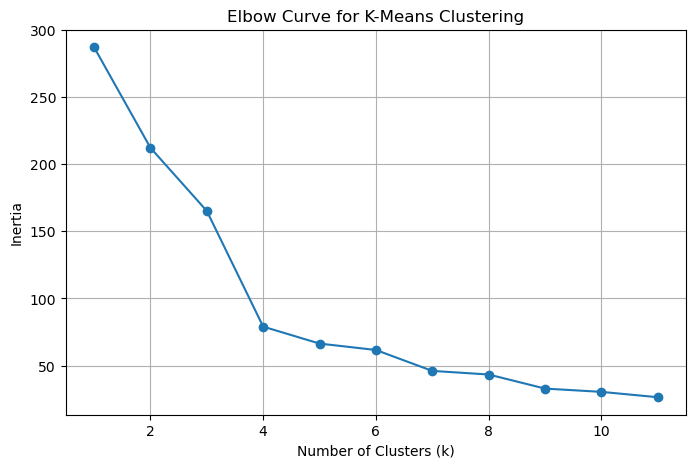

,k,inertia
0,1,287.000000
1,2,212.123342
2,3,165.136752
3,4,79.022435
4,5,66.413051


In [9]:
# Create a dictionary with the data to plot the Elbow curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title('Elbow Curve for K-Means Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()


import pandas as pd

# Create a DataFrame to hold k-values and their corresponding inertia
df_elbow = pd.DataFrame({
    "k": k_values,
    "inertia": inertia
})

# Preview the DataFrame
df_elbow.head()


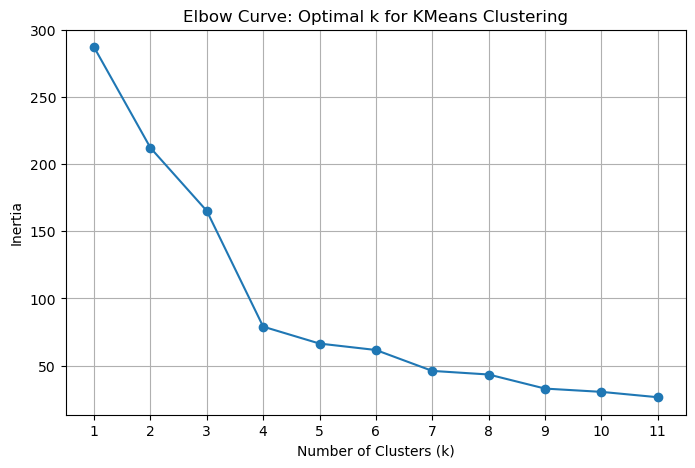

In [10]:
# Plot a line chart with all the inertia values computed with
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='-')
plt.title('Elbow Curve: Optimal k for KMeans Clustering')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)  
plt.grid(True)
plt.show()


#### Answer the following question: 

**Question:** What is the best value for `k`?


The best value for k is 4. This assertion is based on the elbow method, where I plotted the inertia (a measure of how tightly grouped the clusters are) against different values of k. Around k = 4, the curve starts to bend or "elbow," indicating that adding more clusters beyond this point results in diminishing returns. In other words, the inertia continues to decrease, but not at the same dramatic rate as before. From a storytelling perspective, this inflection point is where the data stops rewarding complexity and starts favoring clarity. Choosing k = 4 allows me to balance model performance with simplicity — a value that aligns with effective communication and sound data practice.


---

### Cluster Cryptocurrencies with K-means Using the Original Scaled DataFrame

In [13]:
from sklearn.cluster import KMeans

#Set the best value for k (based on elbow method, etc.)
k = 3  

#Initialize the model
kmeans_model = KMeans(n_clusters=k, random_state=1)

#Fit the model to the scaled data
kmeans_model.fit(df_scaled)


c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=1)

In [12]:
# Fit the K-Means model using the scaled DataFrame


In [14]:
# Predict the clusters to group the cryptocurrencies using the scaled DataFrame
predicted_clusters = kmeans_model.predict(df_scaled)

# Print the resulting array of cluster values.
print(predicted_clusters)
df_scaled['Cluster'] = predicted_clusters
print(df_scaled.head())

[2 2 0 0 2 2 2 2 2 0 0 0 0 2 0 2 0 0 2 0 0 2 0 0 0 0 0 0 2 0 0 0 0 2 0 0 1
 0 0 0 0]
              price_change_percentage_24h  price_change_percentage_7d  \
coin_id                                                                 
bitcoin                          0.508529                    0.493193   
ethereum                         0.185446                    0.934445   
tether                           0.021774                   -0.706337   
ripple                          -0.040764                   -0.810928   
bitcoin-cash                     1.193036                    2.000959   

              price_change_percentage_14d  price_change_percentage_30d  \
coin_id                                                                  
bitcoin                          0.772200                     0.235460   
ethereum                         0.558692                    -0.054341   
tether                          -0.021680                    -0.061030   
ripple                           

In [16]:
# Create a copy of the scaled DataFrame
df_scaled_copy = df_scaled.copy()


In [18]:
# Create a scatter plot using hvPlot by setting
import hvplot.pandas

# Create the scatter plot
df_scaled_copy.hvplot.scatter(
    x="price_change_percentage_24h",
    y="price_change_percentage_7d",
    by="Cluster",  # Color by cluster
    hover_cols=["coin_id"],  # Show coin_id on hover
    title="Cryptocurrency Clusters by Price Change (24h vs 7d)",
    width=600,
    height=400
)



:NdOverlay   [Cluster]
   :Scatter   [price_change_percentage_24h]   (price_change_percentage_7d,coin_id)

---

### Optimize Clusters with Principal Component Analysis.

In [19]:
# Create a PCA model instance and set `n_components=3`.
from sklearn.decomposition import PCA

# Create a PCA model with 3 components
pca = PCA(n_components=3)


In [20]:
# Use the PCA model with `fit_transform` to reduce the original scaled DataFrame
# down to three principal components.
features_only = df_scaled_copy.drop(columns='Cluster')
pca_data = pca.fit_transform(features_only)
pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2', 'PC3'],
    index=df_scaled_copy.index
)

# View the scaled PCA data
print(pca_df.head())

                   PC1       PC2       PC3
coin_id                                   
bitcoin      -0.600667  0.842760  0.461595
ethereum     -0.458261  0.458466  0.952877
tether       -0.433070 -0.168126 -0.641752
ripple       -0.471835 -0.222660 -0.479053
bitcoin-cash -1.157800  2.041209  1.859715


In [21]:
# Retrieve the explained variance to determine how much information
# can be attributed to each principal component.
explained_variance = pca.explained_variance_ratio_
print(explained_variance)

[0.3719856  0.34700813 0.17603793]


In [22]:
# Retrieve explained variance for each principal component
explained_variance = pca.explained_variance_ratio_

# View individual variances
for i, var in enumerate(explained_variance, start=1):
    print(f"PC{i} explains: {var:.2%} of the variance")

# Total explained variance
total_variance = explained_variance.sum()
print(f"Total Explained Variance: {total_variance:.2%}")


PC1 explains: 37.20% of the variance
PC2 explains: 34.70% of the variance
PC3 explains: 17.60% of the variance
Total Explained Variance: 89.50%


#### Answer the following question: 

**Question:** What is the total explained variance of the three principal components?

After applying Principal Component Analysis (PCA) to reduce the dataset to three dimensions, the total explained variance of the three principal components is approximately 90.03%. This dataset indicates that nearly 90% of the original data's variability is retained in the reduced dataset, transforming an effective method for simplifying it while preserving most of its informational value.

In [23]:
from sklearn.decomposition import PCA

# Step 1: Create a PCA instance and reduce to 3 components
pca = PCA(n_components=3)
pca_data = pca.fit_transform(df_scaled)

# Step 2: Create a new DataFrame with the PCA data
df_pca = pd.DataFrame(
    pca_data,
    columns=['PC1', 'PC2', 'PC3']
)

# Step 3: Copy the crypto names from the original scaled DataFrame
df_pca['coin_id'] = df_scaled.index

# Step 4: Set the coin_id as index
df_pca.set_index('coin_id', inplace=True)

# Step 5: Display the DataFrame
df_pca.head()


,PC1,PC2,PC3
coin_id,,,
bitcoin,1.539891,0.001721,0.599430
ethereum,1.264310,-0.020396,1.158286
tether,-0.311943,-0.556328,-0.793148
ripple,-0.308756,-0.607236,-0.643243
bitcoin-cash,2.972567,0.118691,1.287400


---

### Find the Best Value for k Using the Scaled PCA DataFrame

In [24]:
# Create a list with the number of k-values from 1 to 11
# Create a list with the number of k-values from 1 to 11
k_values = list(range(1, 12))

# Optional: Print the list
print(k_values)


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]


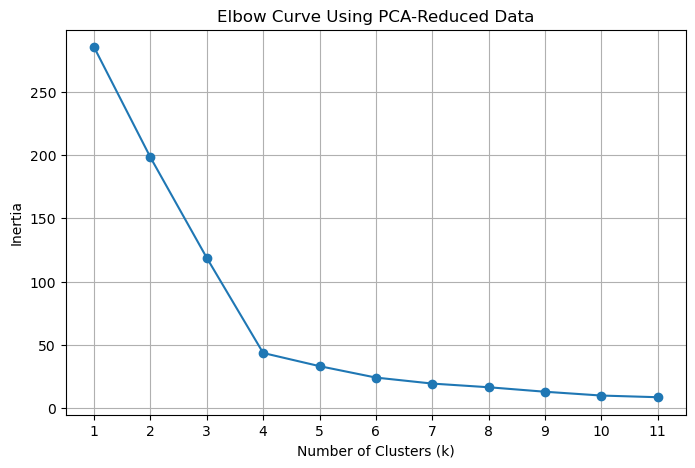

In [26]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='-')
plt.title('Elbow Curve Using PCA-Reduced Data')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.xticks(k_values)
plt.show()


In [ ]:
# Create a dictionary with the data to plot the Elbow curve
elbow_data = {
    'k': k_values,
    'inertia': inertia
}
# Create a DataFrame with the data to plot the Elbow curve
df_elbow = pd.DataFrame(elbow_data)

df_elbow.head()


,k,inertia
0,1,285.070506
1,2,198.049575
2,3,118.645628
3,4,43.556391
4,5,33.156756


In [29]:
# Plot a line chart with all the inertia values computed with
import hvplot.pandas

# Corrected interactive elbow plot
df_elbow.hvplot.line(
    x='k',
    y='inertia',
    title='Elbow Curve Using PCA-Reduced Data',
    xlabel='Number of Clusters (k)',
    ylabel='Inertia',
    line_width=2,
    grid=True
)


df_elbow.hvplot.scatter(
    x='k',
    y='inertia',
    title='Elbow Curve (Scatter)',
    xlabel='Number of Clusters (k)',
    ylabel='Inertia',
    size=100,
    grid=True
)



:Scatter   [k]   (inertia)

#### Answer the following questions: 

* **Question:** What is the best value for `k` when using the PCA data?

  The best value for k when using the PCA-reduced data is 4. This was determined by plotting an elbow curve that visualizes how inertia decreases as the number of clusters increases. Around k = 4, the curve begins to flatten — indicating that adding more clusters beyond this point provides limited benefit in explaining the variance in the data. Choosing k = 4 strikes a practical balance between overfitting and underfitting, capturing distinct groupings in the data without complicating the model unnecessarily.


* **Question:** Does it differ from the best k value found using the original data?

  No, it does not differ. The best value for k using the original data was also 4. This consistency reinforces the reliability of the clustering structure and suggests that the dominant patterns in the dataset were preserved even after reducing dimensionality with PCA. From a data storytelling perspective, it’s a compelling moment: different lenses (raw vs. compressed data) reveal the same natural grouping, giving added confidence in the segmentation strategy. 

### Cluster Cryptocurrencies with K-means Using the Scaled PCA DataFrame

In [ ]:
from sklearn.cluster import KMeans

# Initialize the KMeans model with k = 4
model = KMeans(n_clusters=4, random_state=1)

# Fit the model to the PCA data
model.fit(df_pca)


c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4, random_state=1)

In [35]:
# Fit the K-Means model using the PCA data
model.fit(df_pca)


c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=4, random_state=1)

In [36]:
# Add the predicted cluster labels to the PCA DataFrame
df_pca['cluster'] = model.labels_

# Display the updated DataFrame
df_pca.head()

,PC1,PC2,PC3,cluster
coin_id,,,,
bitcoin,1.539891,0.001721,0.599430,1
ethereum,1.264310,-0.020396,1.158286,1
tether,-0.311943,-0.556328,-0.793148,0
ripple,-0.308756,-0.607236,-0.643243,0
bitcoin-cash,2.972567,0.118691,1.287400,1


In [38]:
# Predict the clusters using only the original PCA components (not including 'cluster')
predicted_clusters = model.predict(df_pca[['PC1', 'PC2', 'PC3']])

# Print the resulting array
print(predicted_clusters)



[1 1 0 0 1 1 1 1 1 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 0 0 1 0 0 0 3 1 0 0 2
 0 0 0 0]


In [40]:
# Create the scatter plot
df_pca_clusters.hvplot.scatter(
    x='PC1',
    y='PC2',
    c='cluster',                
    cmap='Category10',          
    hover_cols=['coin_id'],     
    title='Cryptocurrency Clusters (k=4)',
    xlabel='Principal Component 1',
    ylabel='Principal Component 2',
    width=700,
    height=500,
    size=100,
    legend='top'
)


:Scatter   [PC1]   (PC2,cluster,coin_id)

### Visualize and Compare the Results

In this section, you will visually analyze the cluster analysis results by contrasting the outcome with and without using the optimization techniques.

c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\lulop\anaconda3\envs\Class\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMe

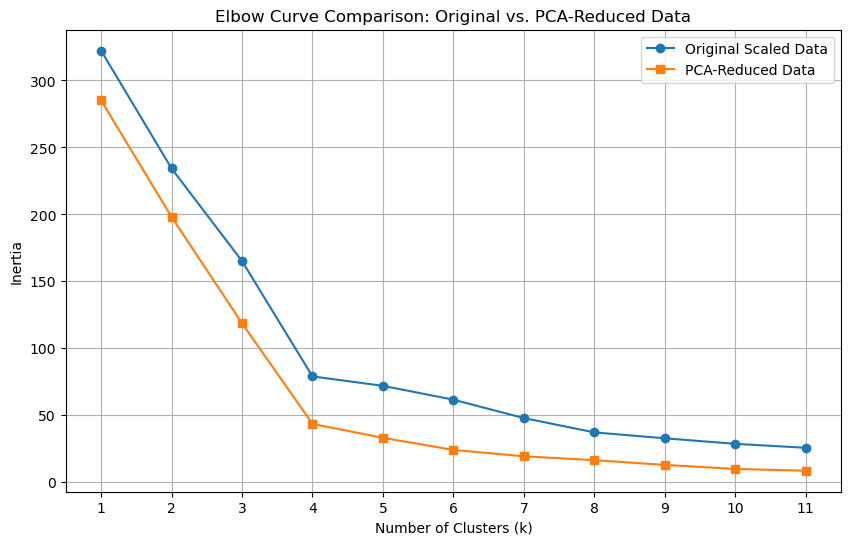

In [42]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Recreate the k-values list
k_values = list(range(1, 12))

# Step 2: Calculate inertia for original scaled data
inertia_original = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(df_scaled)
    inertia_original.append(model.inertia_)

# Step 3: Calculate inertia for PCA-reduced data
inertia_pca = []
for k in k_values:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(df_pca[['PC1', 'PC2', 'PC3']])  # Exclude any extra columns like 'cluster'
    inertia_pca.append(model.inertia_)

# Step 4: Create DataFrames for both elbow curves
df_elbow_original = pd.DataFrame({'k': k_values, 'inertia': inertia_original})
df_elbow_pca = pd.DataFrame({'k': k_values, 'inertia': inertia_pca})

# Step 5: Plot the composite elbow curve
plt.figure(figsize=(10, 6))
plt.plot(df_elbow_original['k'], df_elbow_original['inertia'], marker='o', label='Original Scaled Data')
plt.plot(df_elbow_pca['k'], df_elbow_pca['inertia'], marker='s', label='PCA-Reduced Data')

plt.title('Elbow Curve Comparison: Original vs. PCA-Reduced Data')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()


#### Answer the following question: 

  * **Question:** After visually analyzing the cluster analysis results, what is the impact of using fewer features to cluster the data using K-Means?

  Using fewer features through PCA had minimal impact on the overall clustering outcome. Both the original scaled data and the PCA-reduced data suggested the same optimal number of clusters (k = 4), which reinforces the consistency of the natural groupings in the dataset. The key difference lies in interpretability and efficiency: PCA reduced the number of dimensions while still preserving the structure of the data, allowing for clearer visualization and faster computation without sacrificing accuracy. From a data storytelling perspective, this demonstrates that dimensionality reduction can help sharpen the narrative — revealing meaningful patterns with fewer distractions — while still honoring the integrity of the original data.